In [1]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [3]:
# import dill
# import os
# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = dill.load(f)


In [4]:
# import pickle
# import os

# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = pickle.load(f)

In [5]:
n_agents = 1000
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:17<00:00, 584.18it/s]


steps:  10000
conclusion:  1.0
conclusion core 1.0


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.424871,0.635097,0.871962,0.542690,0.315059,0.390281,0.615616,0.940008,0.785137,0.249666,...,0.632320,0.714509,0.810131,0.866649,0.634600,0.291223,0.839575,0.899704,0.829086,0.236287
1,0.434673,0.608770,0.866506,0.512791,0.318522,0.378921,0.625037,0.933372,0.790486,0.257234,...,0.619206,0.697914,0.790983,0.862907,0.621519,0.321814,0.819219,0.914507,0.818640,0.229145
2,0.472326,0.606863,0.871066,0.526768,0.316788,0.375163,0.641754,0.934849,0.765641,0.255708,...,0.609731,0.697914,0.776062,0.859077,0.610164,0.346729,0.820401,0.912611,0.791033,0.216675


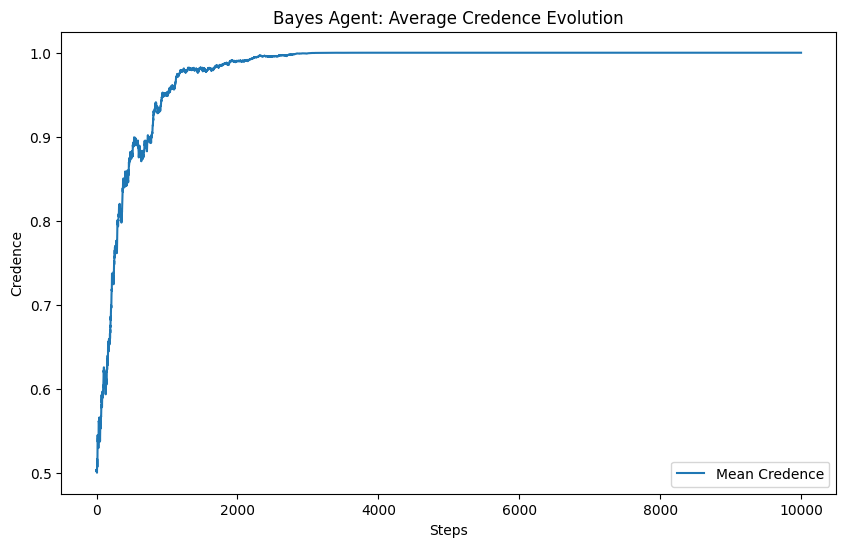

In [7]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [8]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:21<00:00, 456.77it/s]


steps:  10000
conclusion:  0.936


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,"[0.32045843849581307, 0.3949943589180644]","[0.5052808564347689, 0.6424359639595681]","[0.5754653845991968, 0.3754632195866693]","[0.3910150886731116, 0.05155944229715918]","[0.7126069612528548, 0.4877391035795986]","[0.7577296003725127, 0.3929488764392466]","[0.3138858481734879, 7.558974838029798e-15]","[0.9105451778096231, 0.47839171273167147]","[0.6130034758574242, 0.8204797025138472]","[0.00511003698395619, 0.9448023149760979]",...,"[0.29442408503491907, 0.13253466632597993]","[0.003423259086351625, 0.3199997364332674]","[0.4618554353712693, 0.9021568992131189]","[0.08106526949125446, 0.9857464932522938]","[0.660551087886096, 0.3174000074690224]","[0.6110699105947159, 1.7908696853243476e-09]","[0.16941608382940082, 0.1659638986451944]","[0.3533941325135008, 0.699661249753729]","[0.18072047323983073, 0.38295722345298344]","[0.21507491790789257, 0.40328425506356]"
1,"[0.5162147510515118, 0.46494861560435463]","[0.581901493710231, 0.5143993347693783]","[0.47029202919342794, 0.5409485000742363]","[0.4614878616111934, 0.427236504358313]","[0.5258652799568792, 0.48611190134605053]","[0.5152544652933371, 0.4710124464413991]","[0.5013965483316666, 0.49228205066514324]","[0.4615623393214495, 0.4717623941715614]","[0.5309761624276447, 0.502993039024719]","[0.4986947332970284, 0.5419976766624859]",...,"[0.49075678735672107, 0.45130473684907935]","[0.48621721015801794, 0.4681951589687822]","[0.5193678485648316, 0.4744425067738585]","[0.48184376896564424, 0.5208248139607213]","[0.5302392443908803, 0.445919882631928]","[0.4759156130869698, 0.4905210388907673]","[0.55630524439611, 0.5090471707158714]","[0.5749590718847725, 0.4938727201624765]","[0.4910978443339453, 0.49047787703714557]","[0.4798484242803302, 0.5106671307462682]"
2,"[0.5204095096712509, 0.464130261498746]","[0.5047187149220619, 0.48797602311804533]","[0.4581237212210993, 0.4984389035318093]","[0.5069795034502422, 0.48243147374620204]","[0.5234087267985015, 0.4877935939792422]","[0.5271662746826024, 0.48618723235018546]","[0.5417778010022376, 0.48210794927705114]","[0.5135469297762528, 0.46442337347000306]","[0.47516495384809543, 0.49528557591983097]","[0.489927628292591, 0.5381755028215006]",...,"[0.4642710609938393, 0.4835053810681429]","[0.4981207042728121, 0.5141591798664197]","[0.5538511957179348, 0.5096278721932983]","[0.4958995590290401, 0.48575047133391575]","[0.5309609456024516, 0.4853271363998192]","[0.48575399296982963, 0.5195549235037749]","[0.5104716520528638, 0.5006778446131814]","[0.5468389851777327, 0.5060569196902587]","[0.5120642619394334, 0.49624769847991507]","[0.5167529822460512, 0.4968439306864579]"


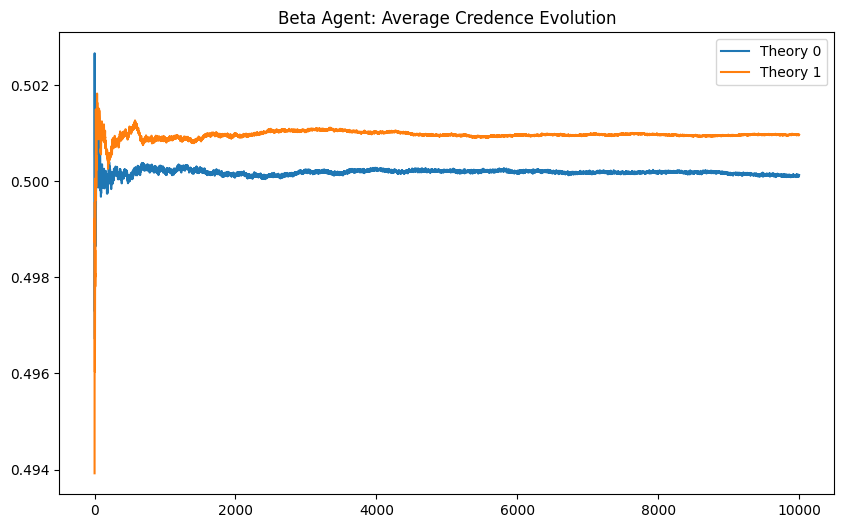

In [9]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

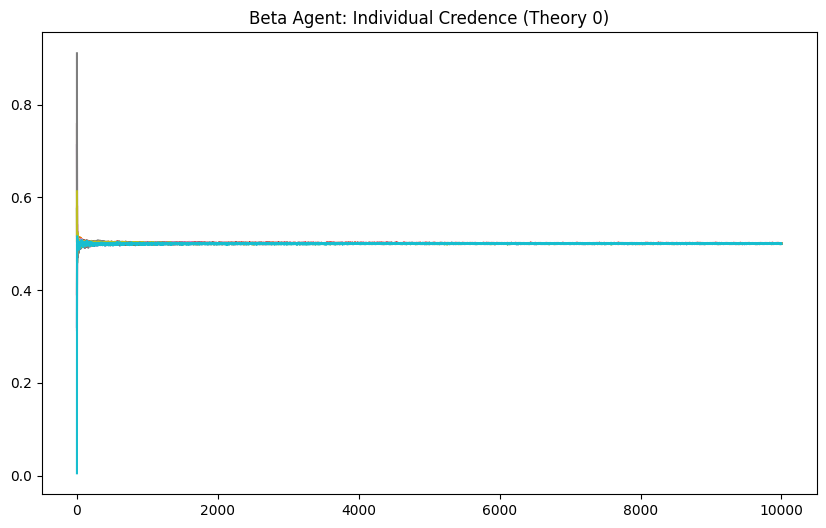

In [10]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()